# Student Performance Indicator

## Life cycle of Machine Learning Project

- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Model Training
- Choose best model

## 1) Problem statement

- This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.

## 2) Data Collection

- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- The data consists of 8 column and 1000 rows.

## 2.1 Import Data and Required Packages

### Importing Pandas, Numpy, Matplotlib, Seaborn and Warnings Library.

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

### Import the CSV Data as Pandas DataFrame

In [8]:
df = pd.read_csv("StudentsPerformance.csv")

### Show Top 5 Records

In [9]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### Shape of the dataset

In [10]:
df.shape

(1000, 8)

## 2.2 Dataset Information

- **gender** : sex of students -> (Male/female)
- **race/ethnicity** : ethnicity of students -> (Group A, B, C, D, E)
- **parental level of education** : parents' final education -> (bachelor's degree, some college, master's degree, associate's degree, high school)
- **lunch** : having lunch before test (standard or free/reduced)
- **test preparation course** : complete or not complete before test
- **math score**
- **reading score**
- **writing score**

## 3. Data Checks to Perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

### 3.1 Check Missing values

In [11]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

**There are no missing values in the data set**

### 3.2 Check Duplicates

In [12]:
df.duplicated().sum()

np.int64(0)

**There are no duplicate values in the data set**

### 3.3 Check data types

In [13]:
# Check Null and Dtypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 103.5 KB


### 3.4 Checking the number of unique values of each column

In [14]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

### 3.5 Check statistics of data set

In [16]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


### Insight

- From above description of numerical data, all means are very close to each other - between 66 and 68.05.
- All standard deviations are also close - between 14.6 and 15.19.
- While there is a minimum score 0 for math, for writing minimum is much higher = 10 and for reading much higher = 17.

## 3.7 Exploring Data

In [17]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [18]:
print("Categories in 'gender' variable: ", end=" ")
print(df['gender'].unique())

print("Categories in 'race/ethnicity' variable: ", end=" ")
print(df['race/ethnicity'].unique())

print("Categories in 'parental level of education' variable: ", end=" ")
print(df['parental level of education'].unique())

print("Categories in 'lunch' variable: ", end=" ")
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable: ", end=" ")
print(df['test preparation course'].unique())

Categories in 'gender' variable:  <ArrowStringArray>
['female', 'male']
Length: 2, dtype: str
Categories in 'race/ethnicity' variable:  <ArrowStringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in 'parental level of education' variable:  <ArrowStringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in 'lunch' variable:  <ArrowStringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in 'test preparation course' variable:  <ArrowStringArray>
['none', 'completed']
Length: 2, dtype: str


In [19]:
# define numerical & categorical columns

numeric_features = df.select_dtypes(include='number').columns.tolist()
categorical_features = df.select_dtypes(exclude='number').columns.tolist()

# print columns

print('We have {} numerical features : {}'.format(
    len(numeric_features), numeric_features
))

print('\nWe have {} categorical features : {}'.format(
    len(categorical_features), categorical_features
))

We have 3 numerical features : ['math score', 'reading score', 'writing score']

We have 5 categorical features : ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [20]:
df.head(2)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


### 3.8 Adding columns for "Total Score" and "Average"

In [21]:
df['total score'] = df['math score'] + df['reading score'] + df['writing score']
df['average'] = df['total score'] / 3

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [22]:
reading_full = (df['reading score'] == 100).sum()
writing_full = (df['writing score'] == 100).sum()
math_full = (df['math score'] == 100).sum()

print(f'Number of students with full marks in Maths: {math_full}')
print(f'Number of students with full marks in Writing: {writing_full}')
print(f'Number of students with full marks in Reading: {reading_full}')

Number of students with full marks in Maths: 7
Number of students with full marks in Writing: 14
Number of students with full marks in Reading: 17


In [23]:
reading_less_20 = (df['reading score'] <= 20).sum()
writing_less_20 = (df['writing score'] <= 20).sum()
math_less_20 = (df['math score'] <= 20).sum()

print(f'Number of students with less than 20 marks in Maths: {math_less_20}')
print(f'Number of students with less than 20 marks in Writing: {writing_less_20}')
print(f'Number of students with less than 20 marks in Reading: {reading_less_20}')

Number of students with less than 20 marks in Maths: 4
Number of students with less than 20 marks in Writing: 3
Number of students with less than 20 marks in Reading: 1


### Insights

- From above values we get students have performed the worst in Maths
- Best performance is in reading section

# 4. Exploring Data (Visualization)

## 4.1 Visualize average score distribution to make some conclusion.

- Histogram
- Kernel Distribution Function (KDE)


### 4.1.1 Histogram & KDE

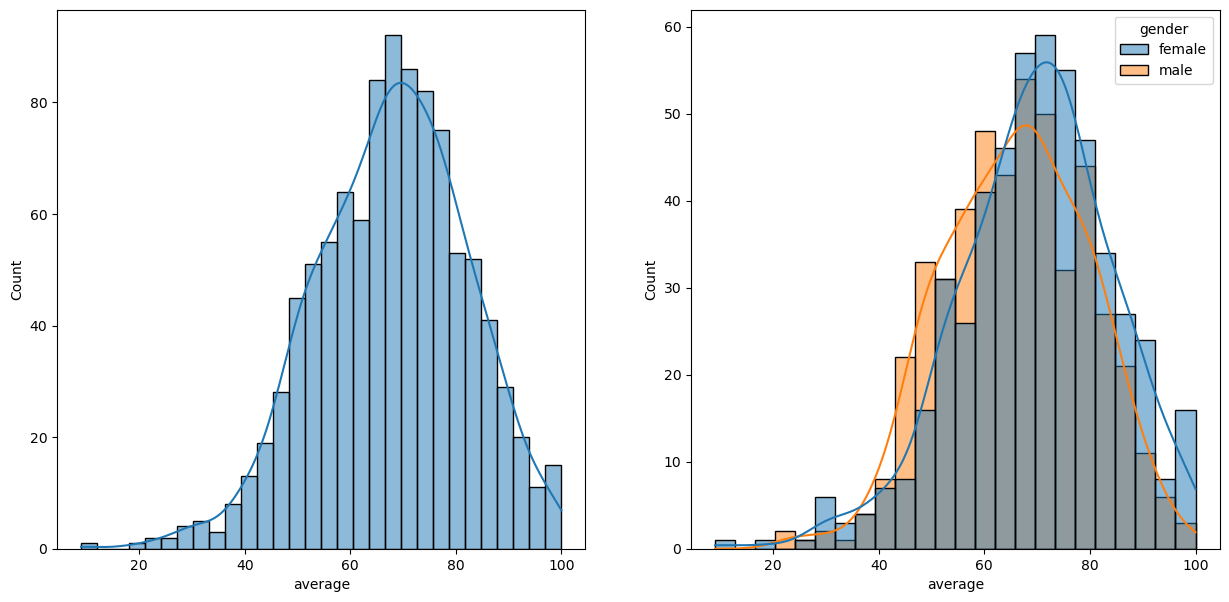

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(15, 7))

sns.histplot(data=df, x='average', bins=30, kde=True, ax=ax[0])

sns.histplot(data=df, x='average', kde=True, hue='gender', ax=ax[1])

plt.show()

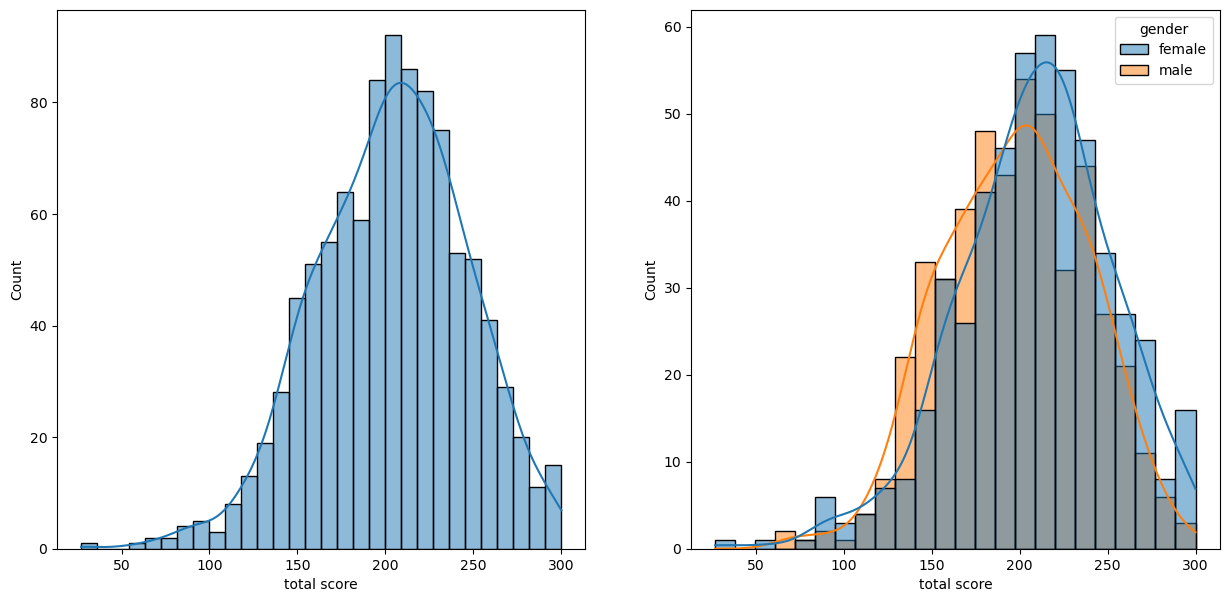

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(15, 7))

sns.histplot(data=df, x='total score', bins=30, kde=True, ax=ax[0])

sns.histplot(data=df, x='total score', kde=True, hue='gender', ax=ax[1])

plt.show()

### Insights

- Female students tend to perform well then male students.

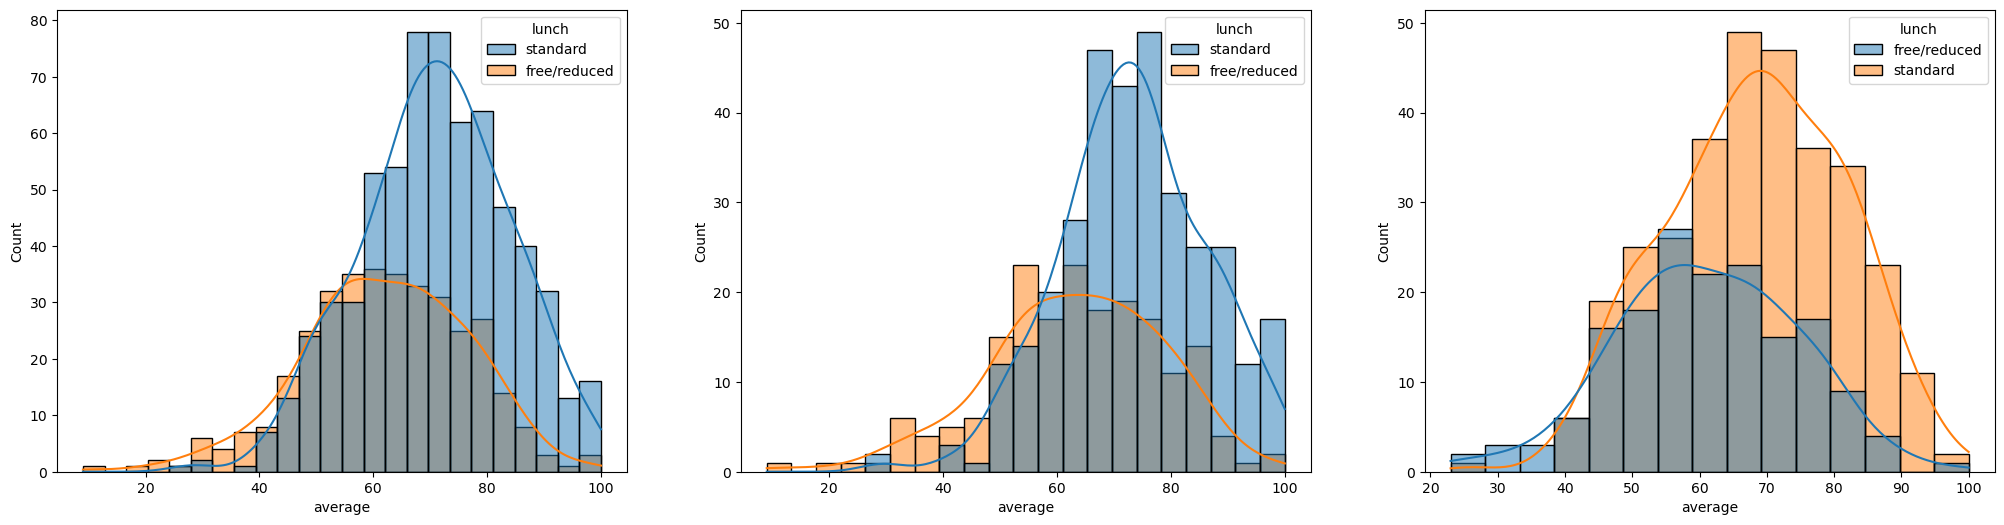

In [26]:
fig, ax = plt.subplots(1, 3, figsize=(25, 6))

sns.histplot(data=df, x='average', kde=True, hue='lunch', ax=ax[0])

sns.histplot(
    data=df[df['gender'] == 'female'],
    x='average',
    kde=True,
    hue='lunch',
    ax=ax[1]
)

sns.histplot(
    data=df[df['gender'] == 'male'],
    x='average',
    kde=True,
    hue='lunch',
    ax=ax[2]
)

plt.show()

### Insights

- Standard lunch helps perform well in exams.
- Standard lunch helps perform well in exams be it a male or a female.

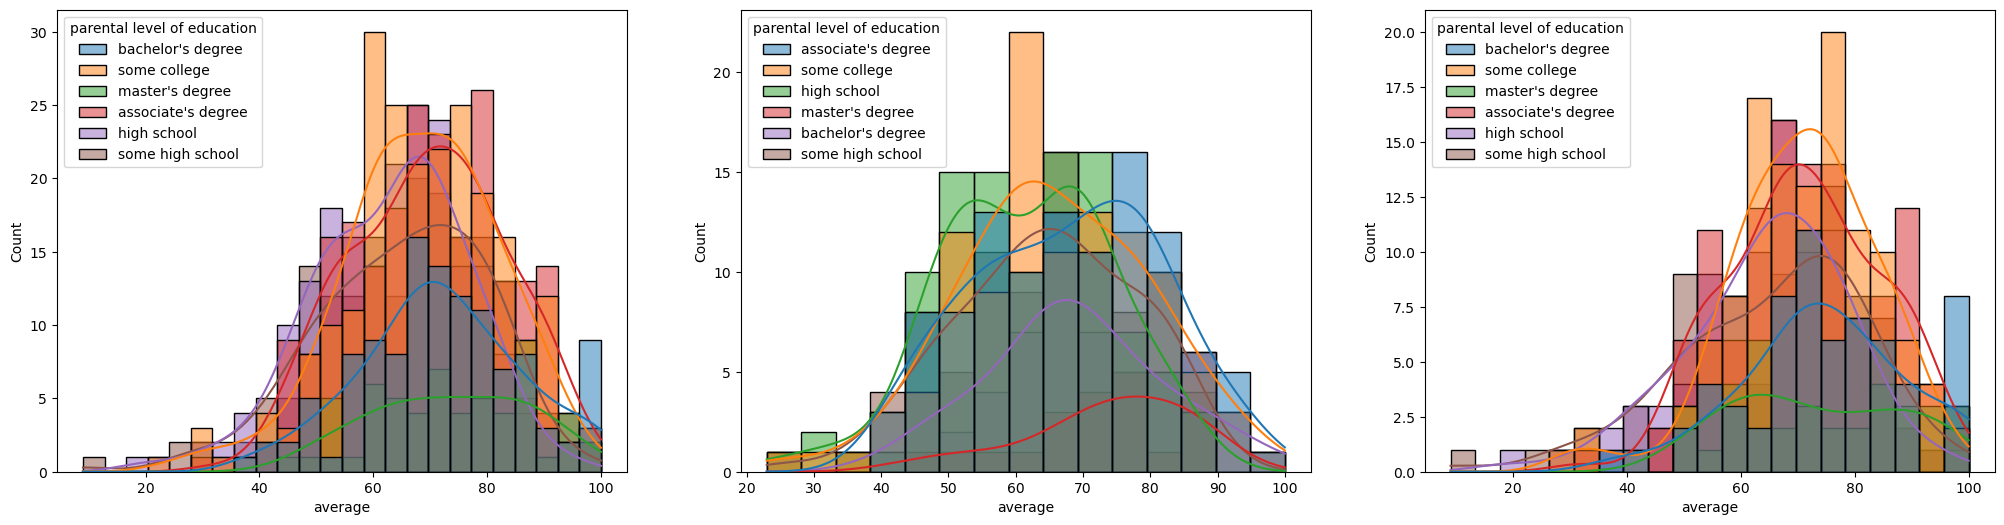

In [27]:
fig, ax = plt.subplots(1, 3, figsize=(25, 6))

sns.histplot(
    data=df,
    x='average',
    kde=True,
    hue='parental level of education',
    ax=ax[0]
)

sns.histplot(
    data=df[df['gender'] == 'male'],
    x='average',
    kde=True,
    hue='parental level of education',
    ax=ax[1]
)

sns.histplot(
    data=df[df['gender'] == 'female'],
    x='average',
    kde=True,
    hue='parental level of education',
    ax=ax[2]
)

plt.show()

### Insights

- In general parent's education don't help student perform well in exam.
- 2nd plot shows that parent's whose education is of associate's degree or master's degree their male child tend to perform well in exam.
- 3rd plot we can see there is no effect of parent's education on female students.

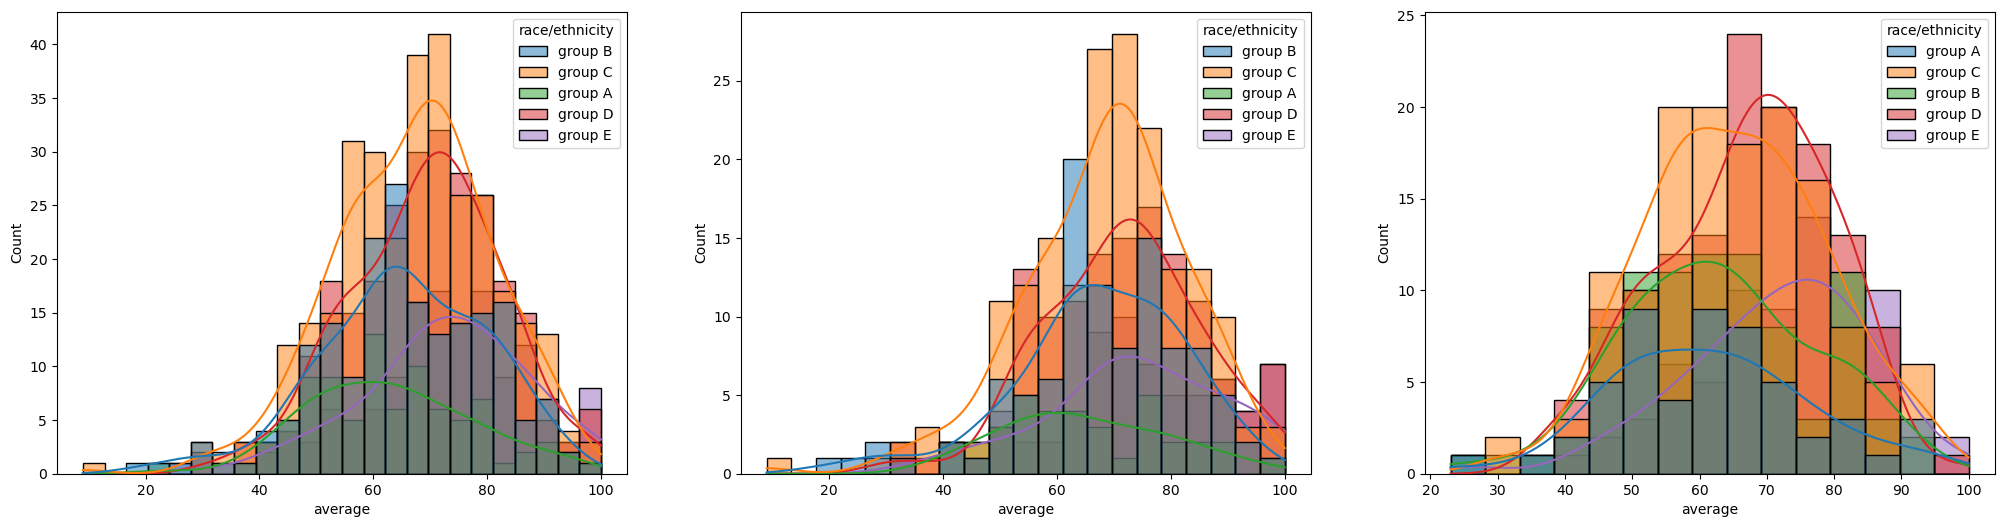

In [28]:
fig, ax = plt.subplots(1, 3, figsize=(25, 6))

sns.histplot(
    data=df,
    x='average',
    kde=True,
    hue='race/ethnicity',
    ax=ax[0]
)

sns.histplot(
    data=df[df['gender'] == 'female'],
    x='average',
    kde=True,
    hue='race/ethnicity',
    ax=ax[1]
)

sns.histplot(
    data=df[df['gender'] == 'male'],
    x='average',
    kde=True,
    hue='race/ethnicity',
    ax=ax[2]
)

plt.show()

### Insights

- Students of group A and group B tends to perform poorly in exam.
- Students of group A and group B tends to perform poorly in exam irrespective of whether they are male or female.

## 4.2 Maximumum score of students in all three subjects

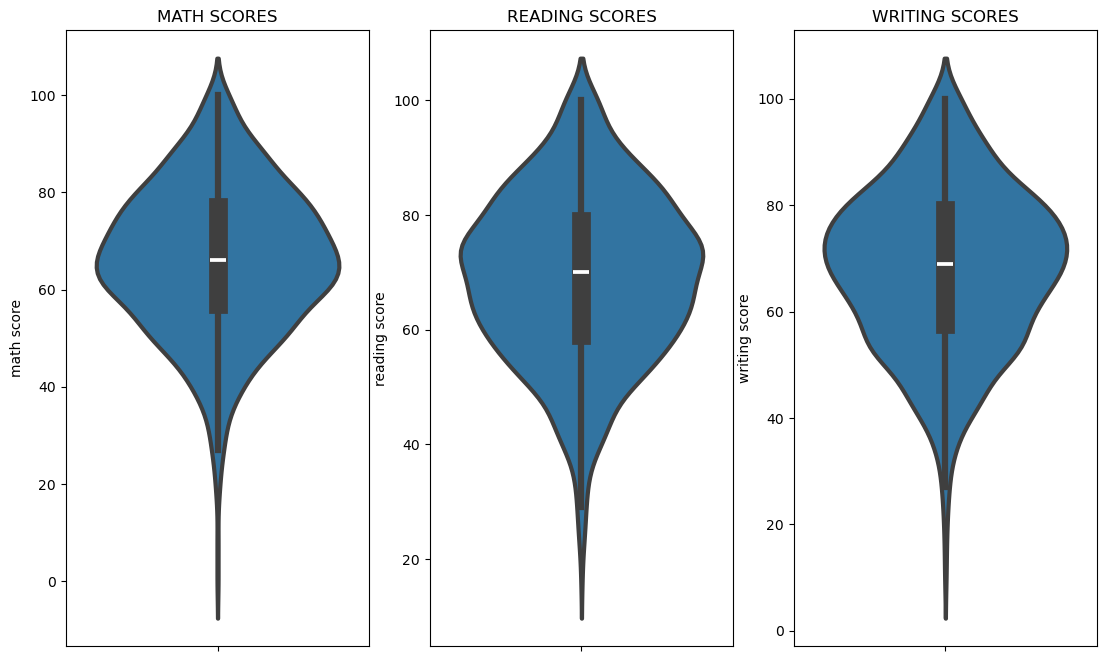

In [29]:
plt.figure(figsize=(18, 8))

plt.subplot(1, 4, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math score', data=df, linewidth=3)

plt.subplot(1, 4, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading score', data=df, linewidth=3)

plt.subplot(1, 4, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing score', data=df, linewidth=3)

plt.show()

### Insights

- From the above three plots its clearly visible that most of the students score in between 60-80 in Maths whereas in reading and writing most of them score from 50-80

## 4.3 Multivariate analysis using pieplot

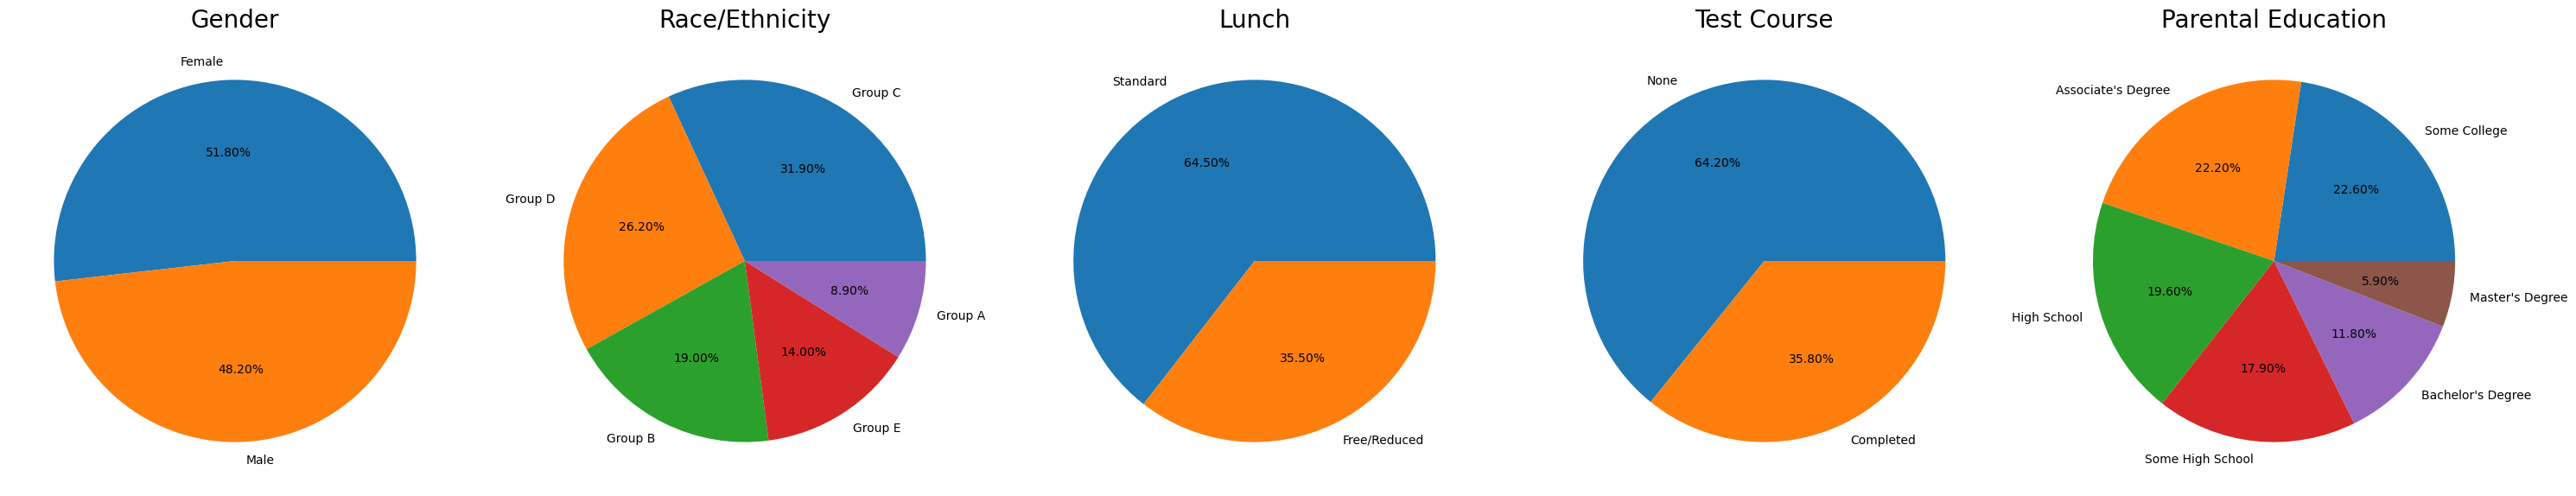

In [30]:
plt.rcParams['figure.figsize'] = (30, 12)

# Gender
plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
labels = ['Female', 'Male']

plt.pie(size, labels=labels, autopct='%.2f%%')
plt.title('Gender', fontsize=20)
plt.axis('off')


# Race/Ethnicity
plt.subplot(1, 5, 2)
size = df['race/ethnicity'].value_counts()
labels = ['Group C', 'Group D', 'Group B', 'Group E', 'Group A']

plt.pie(size, labels=labels, autopct='%.2f%%')
plt.title('Race/Ethnicity', fontsize=20)
plt.axis('off')


# Lunch
plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
labels = ['Standard', 'Free/Reduced']

plt.pie(size, labels=labels, autopct='%.2f%%')
plt.title('Lunch', fontsize=20)
plt.axis('off')


# Test Preparation Course
plt.subplot(1, 5, 4)
size = df['test preparation course'].value_counts()
labels = ['None', 'Completed']

plt.pie(size, labels=labels, autopct='%.2f%%')
plt.title('Test Course', fontsize=20)
plt.axis('off')


# Parental Education
plt.subplot(1, 5, 5)
size = df['parental level of education'].value_counts()
labels = [
    'Some College',
    "Associate's Degree",
    'High School',
    'Some High School',
    "Bachelor's Degree",
    "Master's Degree"
]

plt.pie(size, labels=labels, autopct='%.2f%%')
plt.title('Parental Education', fontsize=20)
plt.axis('off')

plt.tight_layout()
plt.grid()
plt.show()

### Insights

- Number of Male and Female students is almost equal
- Number students are greatest in Group C
- Number of students who have standard lunch are greater
- Number of students who have not enrolled in any test preparation course is greater
- Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree"

## 4.4 Feature Wise Visualization

### 4.4.1 GENDER COLUMN

- How is distribution of Gender ?
- Is gender has any impact on student's performance ?

### UNIVARIATE ANALYSIS (How is distribution of Gender ?)

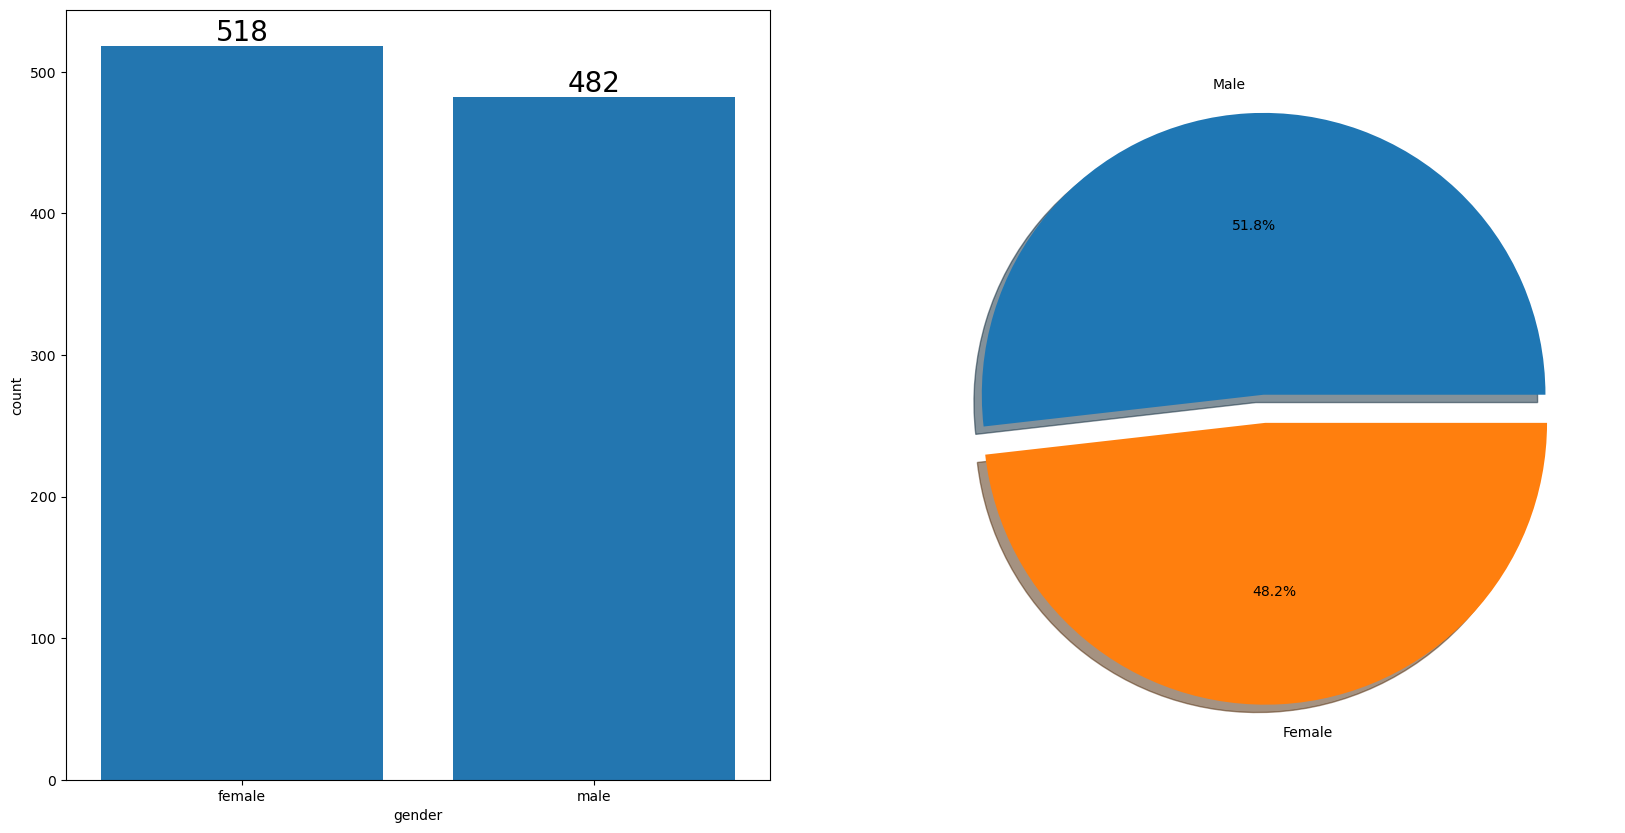

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

sns.countplot(
    x=df['gender'],
    data=df,
    ax=ax[0],
    saturation=0.95
)

for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=20)

plt.pie(
    x=df['gender'].value_counts(),
    labels=['Male', 'Female'],
    explode=[0, 0.1],
    autopct='%1.1f%%',
    shadow=True
)

plt.show()

### Insights

- The dataset is fairly balanced by gender, with 518 female students (51.8%) and 482 male students (48.2%).

### BIVARIATE ANALYSIS (Is gender has any impact on student's performance ?)

In [32]:
gender_group = df.groupby('gender').mean(numeric_only=True)

gender_group

,math score,reading score,writing score,total score,average
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


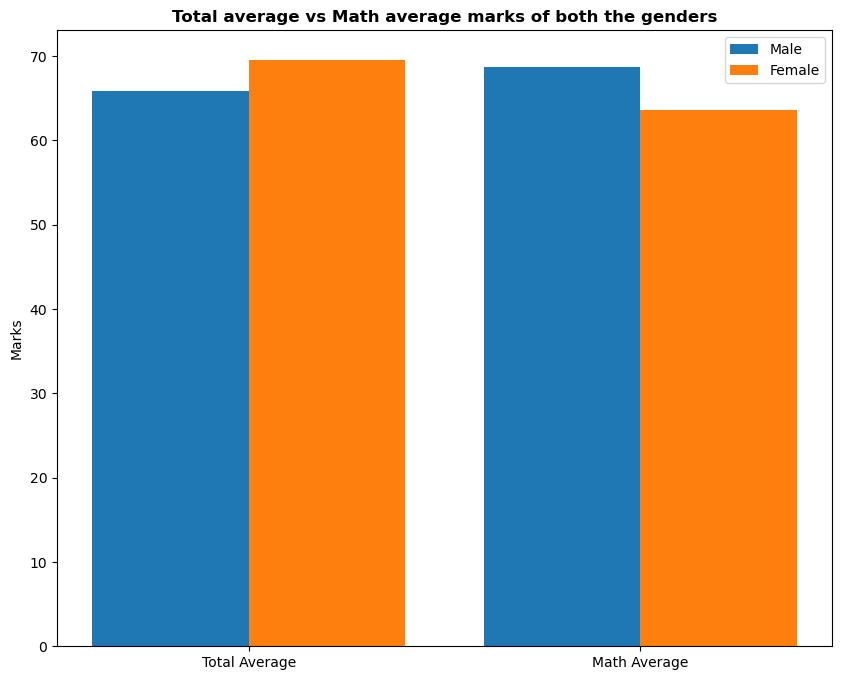

In [33]:
plt.figure(figsize=(10, 8))

X = ['Total Average', 'Math Average']

female_scores = [
    gender_group['average'].iloc[0],
    gender_group['math score'].iloc[0]
]

male_scores = [
    gender_group['average'].iloc[1],
    gender_group['math score'].iloc[1]
]

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, male_scores, 0.4, label='Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label='Female')

plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total average vs Math average marks of both the genders", fontweight='bold')
plt.legend()

plt.show()

### Insights

- On an average females have a better overall score than men.
- Whereas males have scored higher in Maths.

## 4.4.2 RACE/ETHNICITY COLUMN

- How is Group wise distribution ?
- Is Race/Ethnicity has any impact on student's performance ?


### UNIVARIATE ANALYSIS (How is Group wise distribution ?)

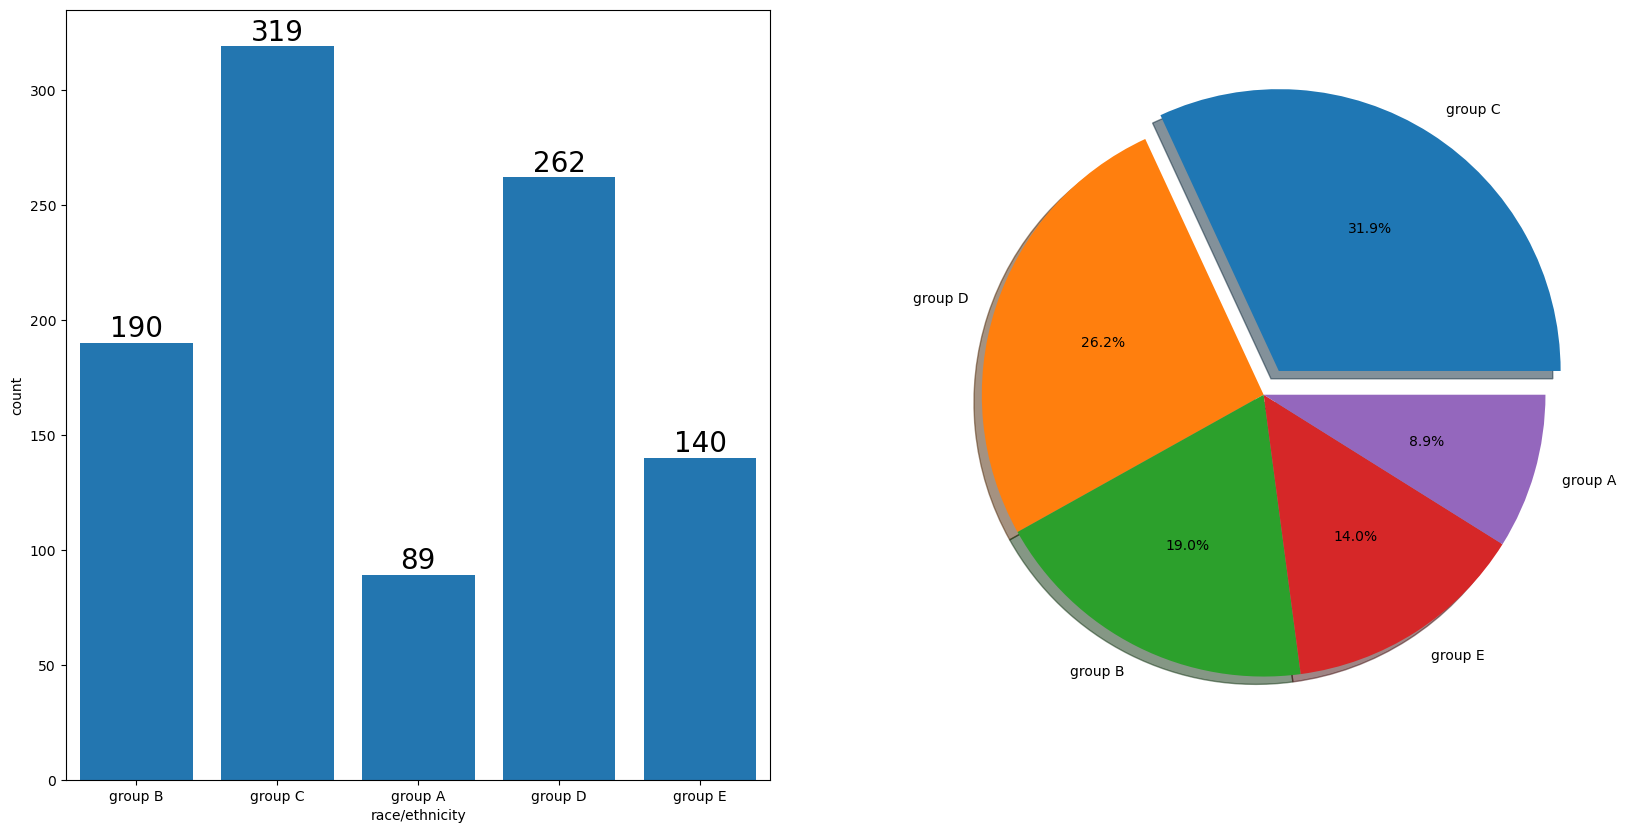

In [34]:
f, ax = plt.subplots(1, 2, figsize=(20, 10))

sns.countplot(
    x=df['race/ethnicity'],
    data=df,
    ax=ax[0],
    saturation=0.95
)

for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=20)

race_counts = df['race/ethnicity'].value_counts()

plt.sca(ax[1])

plt.pie(
    race_counts,
    labels=race_counts.index,
    explode=[0.1, 0, 0, 0, 0],
    autopct='%1.1f%%',
    shadow=True
)

plt.show()

### Insights

- Most of the student belonging from group C / group D.
- Lowest number of students belong to group A.

### BIVARIATE ANALYSIS (Is Race/Ethnicity has any impact on student's performance ?)

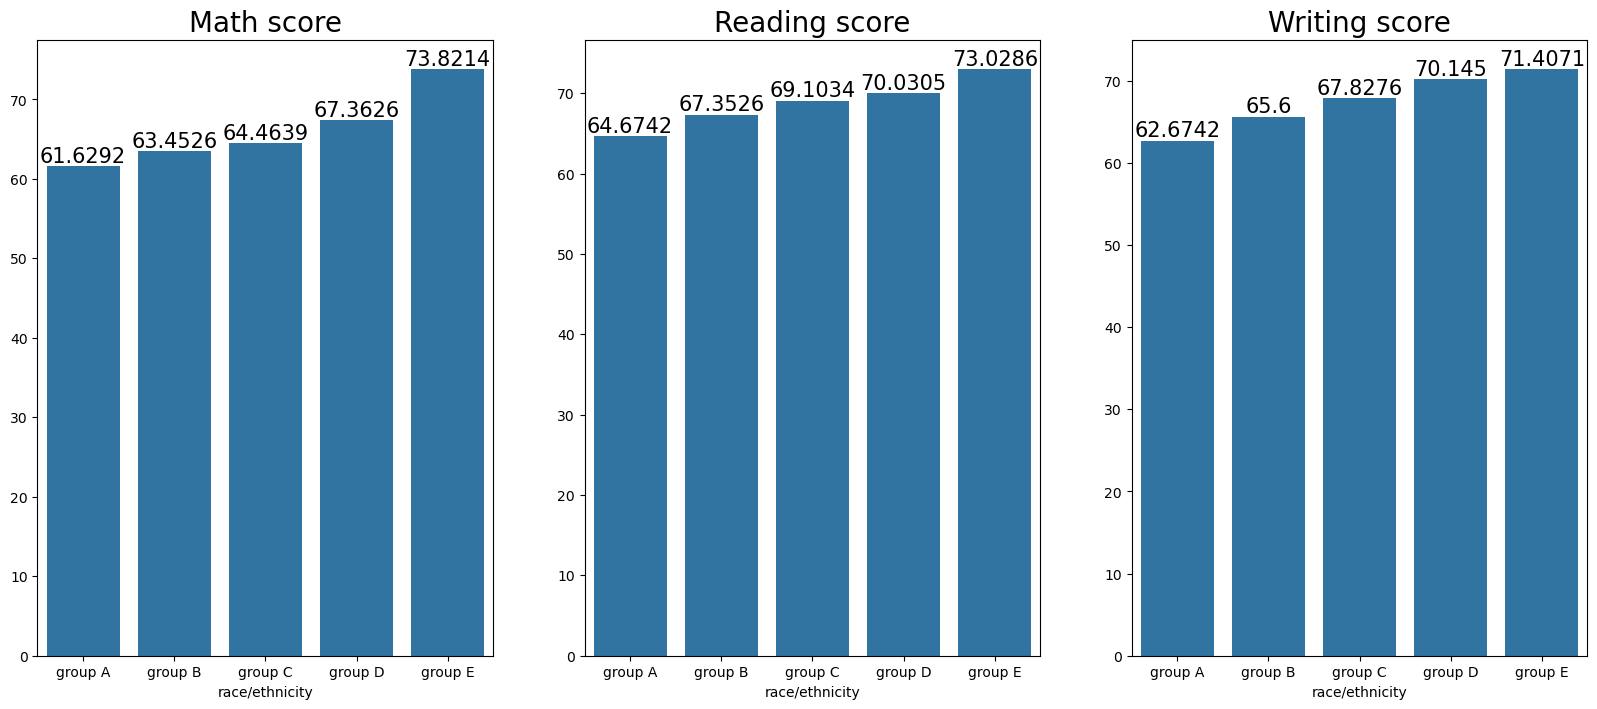

In [35]:
Group_data2 = df.groupby('race/ethnicity')

f, ax = plt.subplots(1, 3, figsize=(20, 8))

# Math score
sns.barplot(
    x=Group_data2['math score'].mean().index,
    y=Group_data2['math score'].mean().values,
    ax=ax[0]
)
ax[0].set_title('Math score', fontsize=20)

for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=15)

# Reading score
sns.barplot(
    x=Group_data2['reading score'].mean().index,
    y=Group_data2['reading score'].mean().values,
    ax=ax[1]
)
ax[1].set_title('Reading score', fontsize=20)

for container in ax[1].containers:
    ax[1].bar_label(container, color='black', size=15)

# Writing score
sns.barplot(
    x=Group_data2['writing score'].mean().index,
    y=Group_data2['writing score'].mean().values,
    ax=ax[2]
)
ax[2].set_title('Writing score', fontsize=20)

for container in ax[2].containers:
    ax[2].bar_label(container, color='black', size=15)

plt.show()

### Insights

- Group E students have scored the highest marks.
- Group A students have scored the lowest marks.
- Students from a lower socioeconomic status have a lower average in all course subjects.

## 4.4.3 PARENTAL LEVEL OF EDUCATION COLUMN

- What is educational background of student's parent ?
- Is parental education has any impact on student's performance ?

### UNIVARIATE ANALYSIS (What is educational background of student's parent ?)

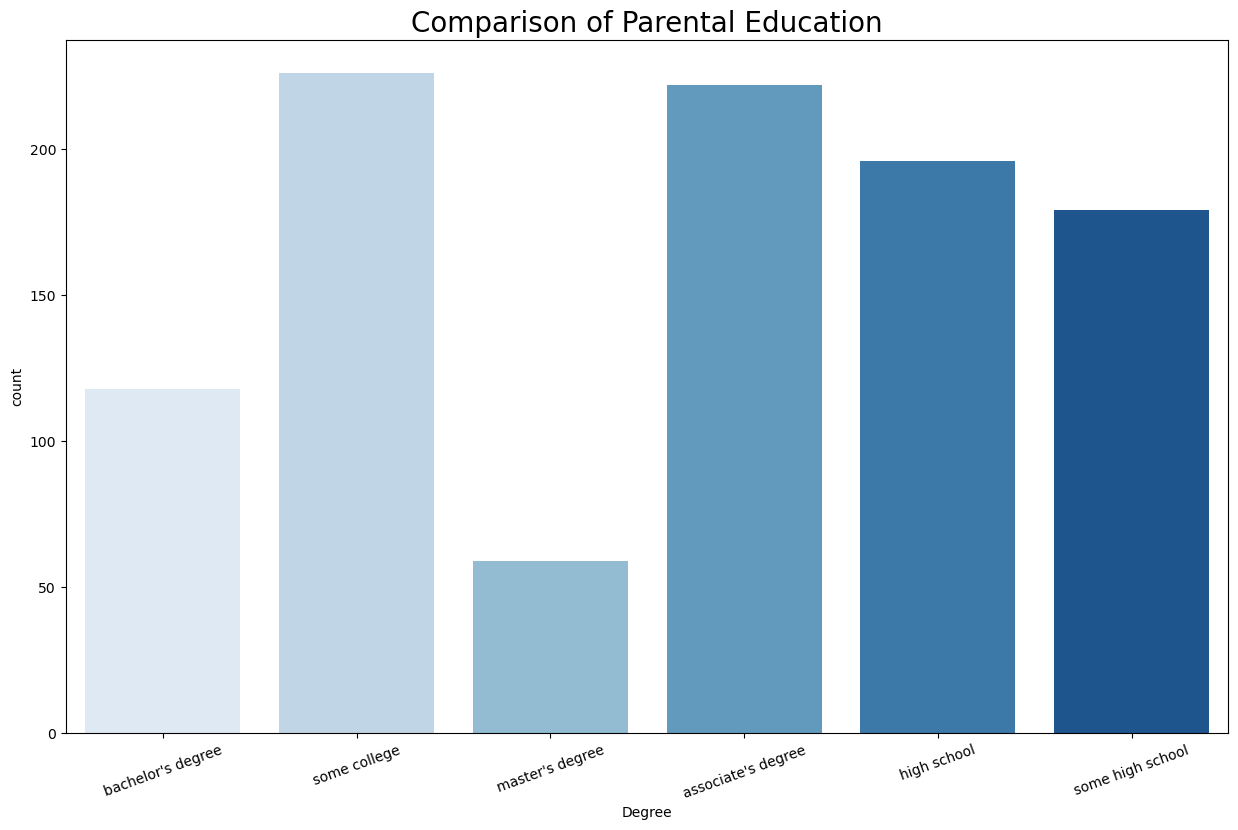

In [36]:
plt.rcParams['figure.figsize'] = (15, 9)

sns.countplot(
    x=df['parental level of education'],
    hue=df['parental level of education'],
    palette='Blues',
    legend=False
)

plt.title(
    'Comparison of Parental Education',
    fontweight=30,
    fontsize=20
)

plt.xlabel('Degree')
plt.ylabel('count')

plt.xticks(rotation=20)

plt.show()

### Insights

- Largest number of parents are from some college.

### BIVARIATE ANALYSIS (Is parental education has any impact on student's performance ?)

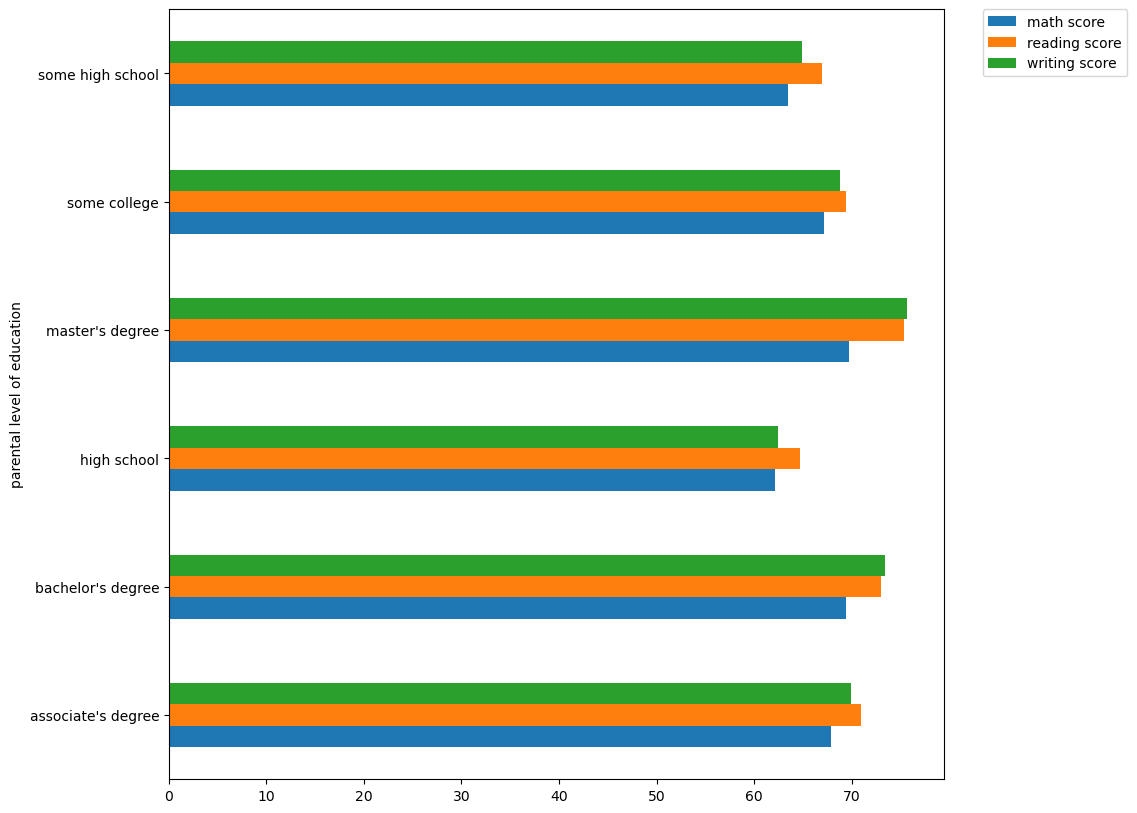

In [37]:
df.groupby('parental level of education')[
    ['math score', 'reading score', 'writing score']
].mean().plot(
    kind='barh',
    figsize=(10, 10)
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc=2,
    borderaxespad=0.
)

plt.show()

### Insights

- The score of student whose parents possess master and bachelor level education are higher than others.

## 4.4.4 LUNCH COLUMN

- Which type of lunch is most common among students ?
- What is the effect of lunch type on test results ?

### UNIVARIATE ANALYSIS (Which type of lunch is most common among students ?)

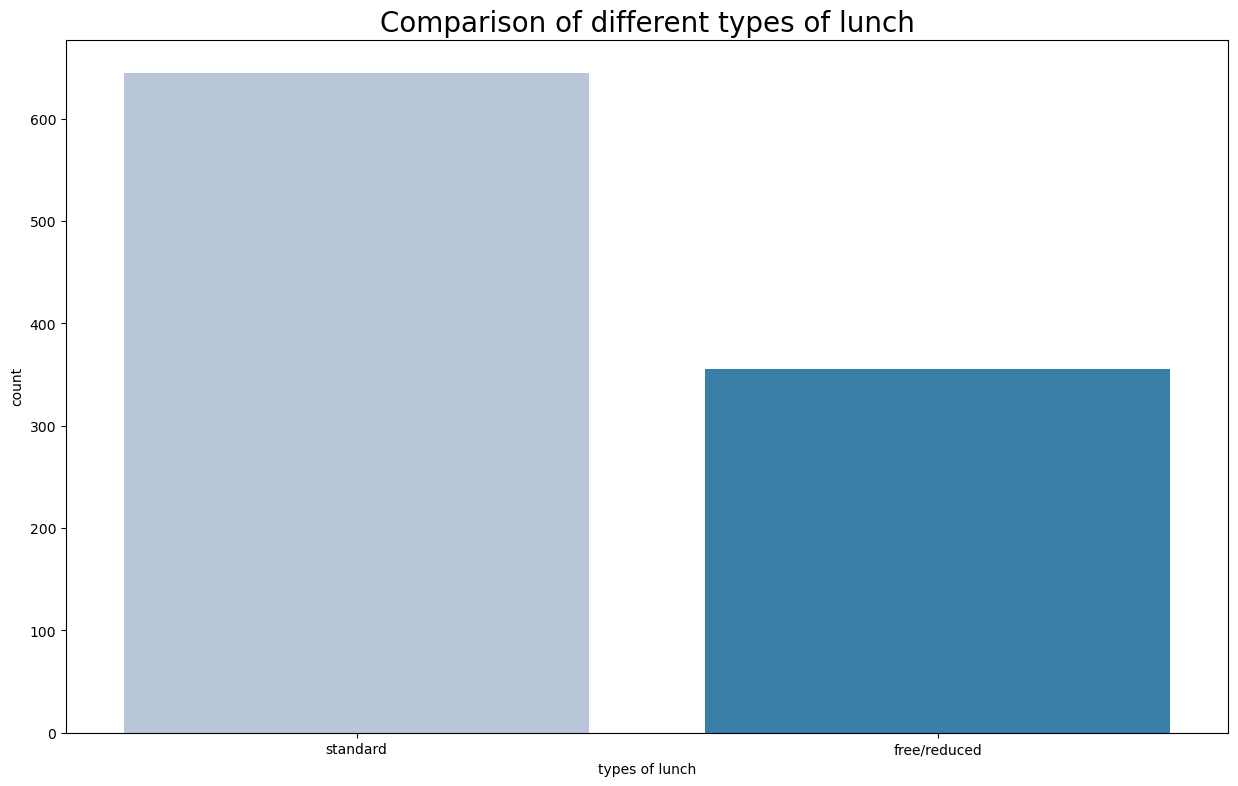

In [38]:
plt.rcParams['figure.figsize'] = (15, 9)

sns.countplot(
    x=df['lunch'],
    hue=df['lunch'],
    palette='PuBu',
    legend=False
)

plt.title(
    'Comparison of different types of lunch',
    fontweight=30,
    fontsize=20
)

plt.xlabel('types of lunch')
plt.ylabel('count')

plt.show()

### Insights

- Students being served Standard lunch was more than free lunch.

### BIVARIATE ANALYSIS (Is lunch type intake has any impact on student's performance ?)

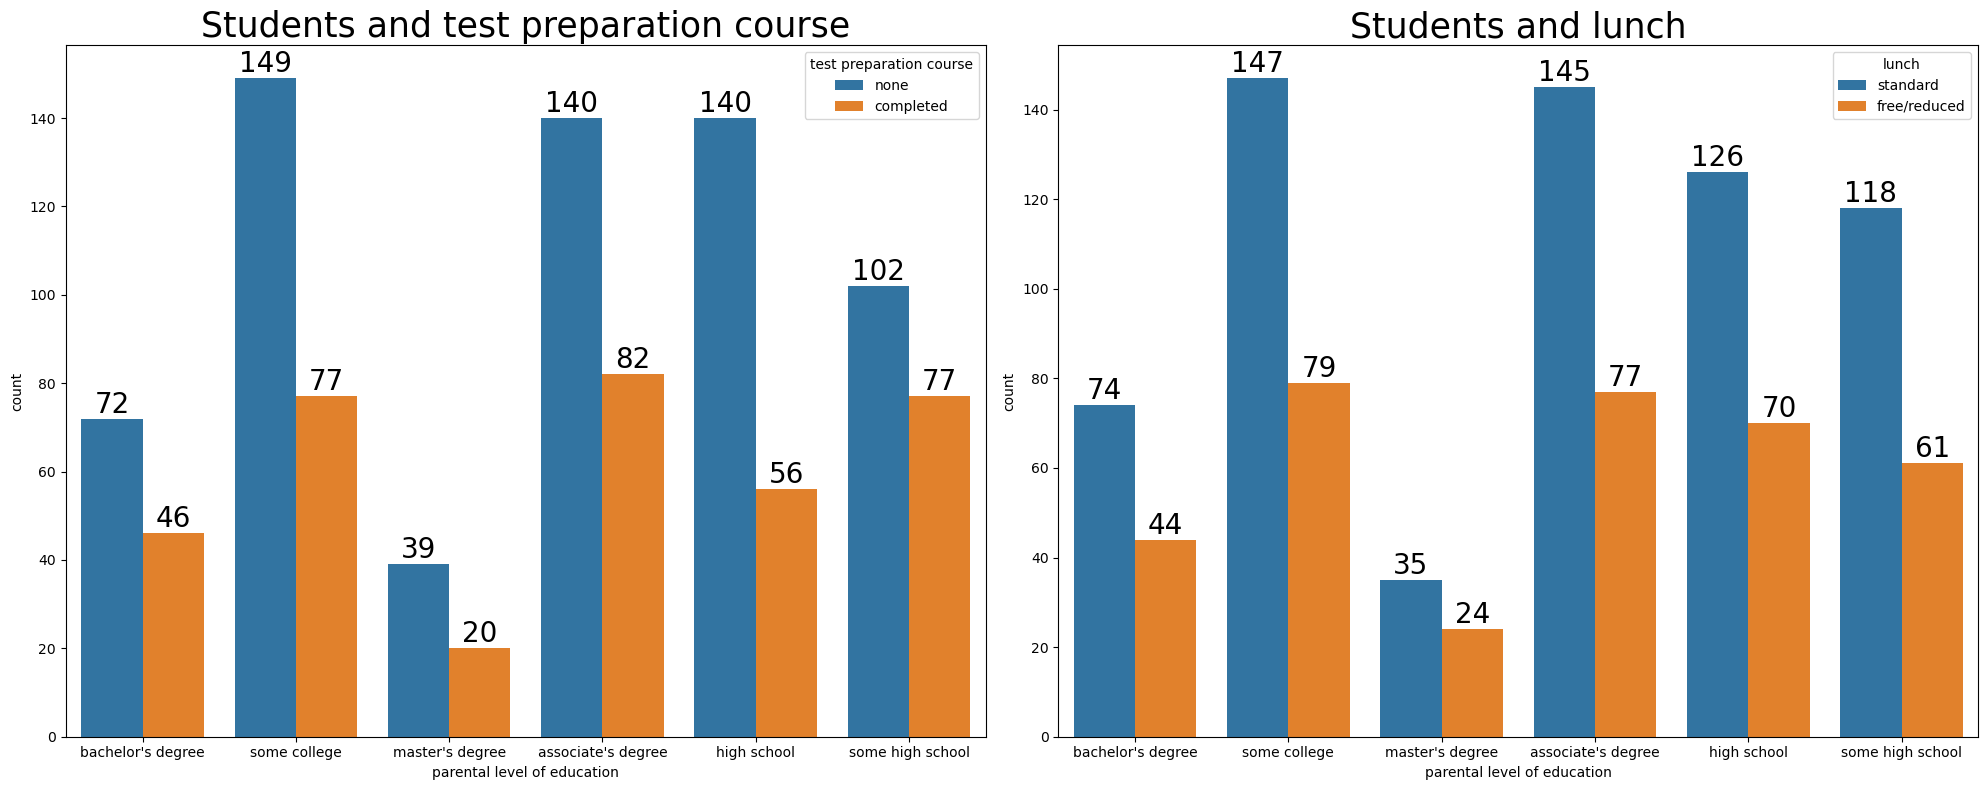

In [39]:
f, ax = plt.subplots(1, 2, figsize=(20, 8))

sns.countplot(
    x=df['parental level of education'],
    data=df,
    hue=df['test preparation course'],
    ax=ax[0]
)

ax[0].set_title(
    'Students and test preparation course',
    color='black',
    size=25
)

for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=20)

sns.countplot(
    x=df['parental level of education'],
    data=df,
    hue=df['lunch'],
    ax=ax[1]
)

ax[1].set_title(
    'Students and lunch',
    color='black',
    size=25
)

for container in ax[1].containers:
    ax[1].bar_label(container, color='black', size=20)

plt.tight_layout()
plt.show()

### Insights

- Students who get Standard Lunch tend to perform better than students who got free/reduced lunch

## 4.4.5 TEST PREPARATION COURSE COLUMN

- Which type of test preparation course is most common among students ?
- Is Test preparation course has any impact on student's performance ?

### BIVARIATE ANALYSIS (Is Test preparation course has any impact on student's performance ?)

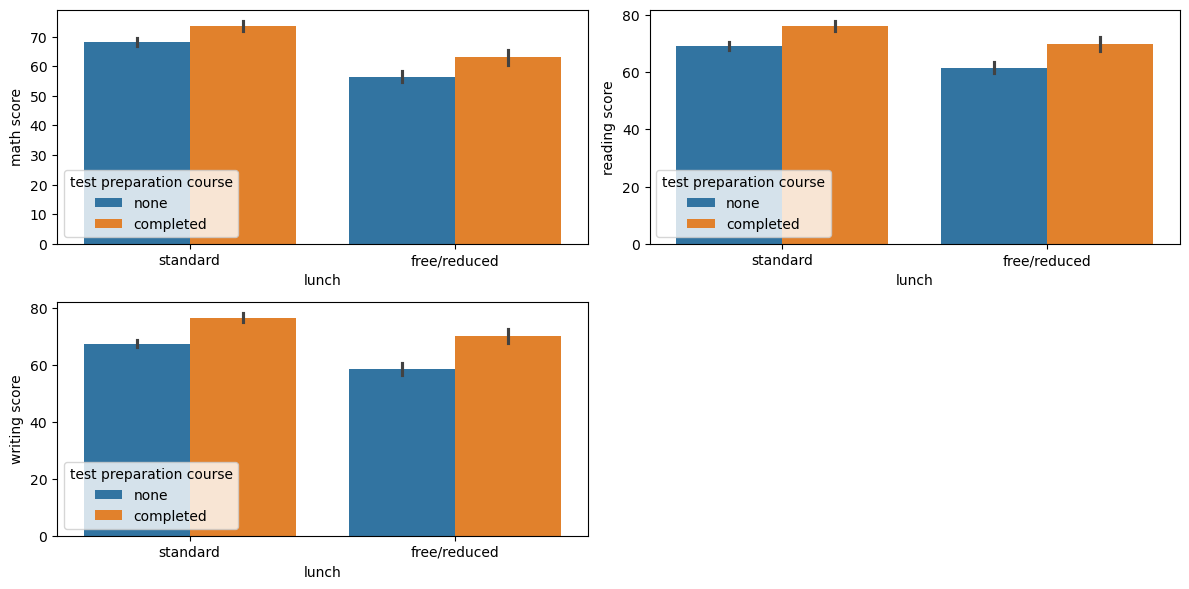

In [40]:
plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
sns.barplot(
    x=df['lunch'],
    y=df['math score'],
    hue=df['test preparation course']
)

plt.subplot(2, 2, 2)
sns.barplot(
    x=df['lunch'],
    y=df['reading score'],
    hue=df['test preparation course']
)

plt.subplot(2, 2, 3)
sns.barplot(
    x=df['lunch'],
    y=df['writing score'],
    hue=df['test preparation course']
)

plt.tight_layout()
plt.show()

### Insights

- Students who have completed the Test Preparation Course have scores higher in all three categories than those who haven't taken the course.

## 4.4.6 CHECKING OUTLIERS

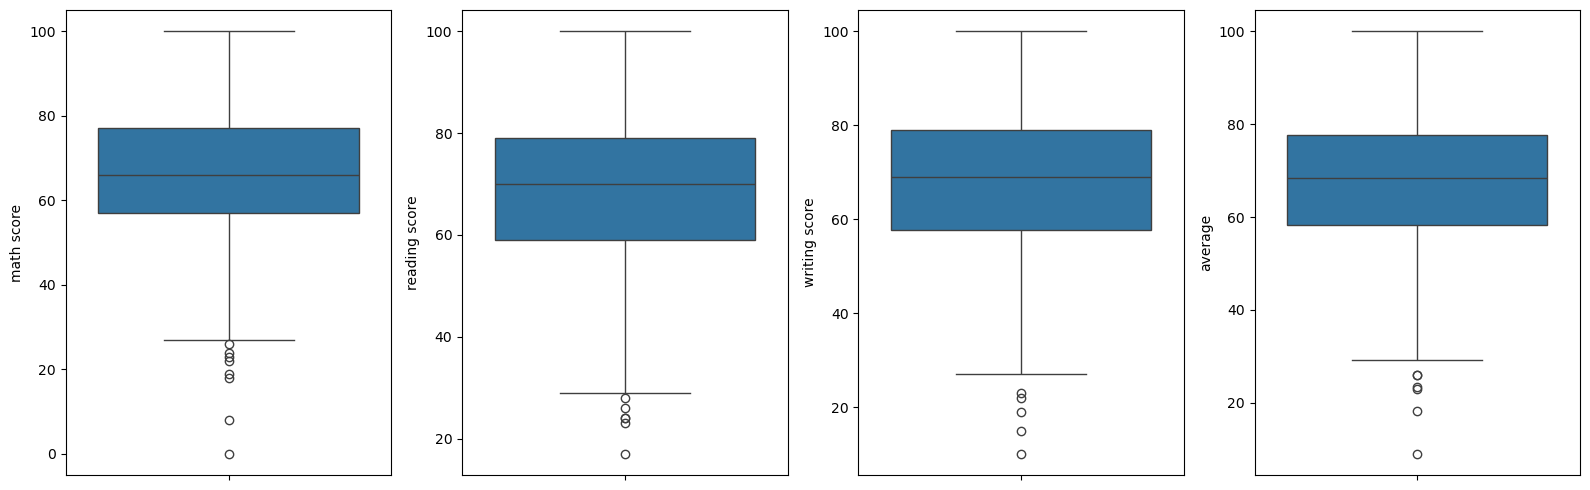

In [41]:
plt.subplots(1, 4, figsize=(16, 5))

plt.subplot(1, 4, 1)
sns.boxplot(y=df['math score'])

plt.subplot(1, 4, 2)
sns.boxplot(y=df['reading score'])

plt.subplot(1, 4, 3)
sns.boxplot(y=df['writing score'])

plt.subplot(1, 4, 4)
sns.boxplot(y=df['average'])

plt.tight_layout()
plt.show()

## 4.4.7 MULTIVARIATE ANALYSIS USING PAIRPLOT

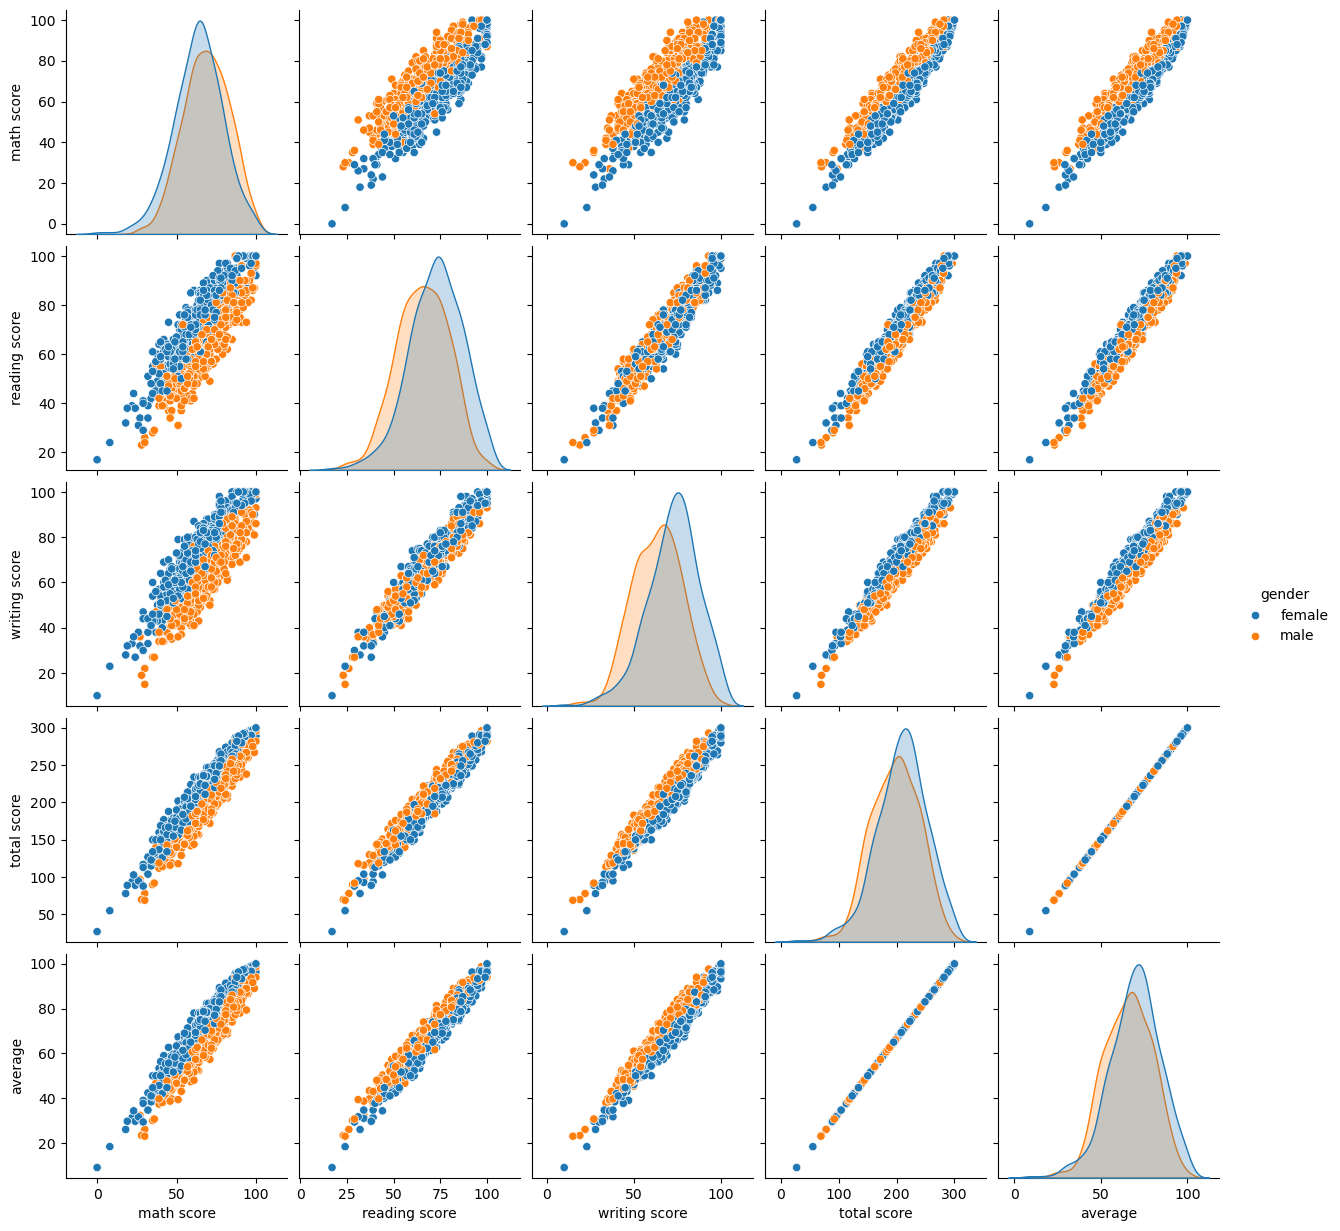

In [42]:
sns.pairplot(df, hue='gender')
plt.show()

### Insights

- From the above plot it is clear that all the scores increase linearly with each other.

# 5. Conclusions

- Student's Performance is related with lunch, race, parental level education
- Females lead in pass percentage and also are top-scorers
- Student's Performance is not much related with test preparation course
- Finishing preparation course is beneficial.

# Model Training

## 1.1 Import Data and Required Packages

Importing Pandas, Numpy, Matplotlib, Seaborn and Machine Learning libraries.

In [2]:
%pip install catboost --retries 10 --timeout 120

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--

In [4]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

## Import the CSV Data as Pandas DataFrame

In [5]:
df = pd.read_csv("StudentsPerformance.csv")

## Show Top 5 Records

In [6]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## Preparing X and Y variables

In [7]:
X = df.drop(columns=['math score'])

In [8]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [9]:
X.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [10]:
print("Categories in 'gender' variable: ", end=" ")
print(df['gender'].unique())

print("Categories in 'race/ethnicity' variable: ", end=" ")
print(df['race/ethnicity'].unique())

print("Categories in 'parental level of education' variable: ", end=" ")
print(df['parental level of education'].unique())

print("Categories in 'lunch' variable: ", end=" ")
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable: ", end=" ")
print(df['test preparation course'].unique())

Categories in 'gender' variable:  <ArrowStringArray>
['female', 'male']
Length: 2, dtype: str
Categories in 'race/ethnicity' variable:  <ArrowStringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in 'parental level of education' variable:  <ArrowStringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in 'lunch' variable:  <ArrowStringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in 'test preparation course' variable:  <ArrowStringArray>
['none', 'completed']
Length: 2, dtype: str


In [11]:
y = df['math score']

In [12]:
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math score, Length: 1000, dtype: int64

## Data Preprocessing

In [13]:
# Create Column Transformer with 2 types of transformers

num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
        ("StandardScaler", numeric_transformer, num_features),
    ]
)

C:\Users\Vyshnavi\AppData\Local\Temp\ipykernel_29616\3892690896.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes(include="object").columns


In [15]:
X.shape

(1000, 19)

## Splitting the dataset into Train and Test

In [16]:
# Separate dataset into train and test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape

((800, 19), (200, 19))

## Create an Evaluation Function

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [18]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    r2_square = r2_score(true, predicted)

    return mae, rmse, r2_square

In [19]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(),
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}

model_list = []
r2_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]

    # Train model
    model.fit(X_train, y_train)

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate Training dataset
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(
        y_train, y_train_pred
    )

    # Evaluate Test dataset
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(
        y_test, y_test_pred
    )

    print(list(models.keys())[i])

    model_list.append(list(models.keys())[i])

    print("Model performance for Training set")
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print("--------------------------------")

    print("Model performance for Test set")
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))

    r2_list.append(model_test_r2)

    print("=" * 35)
    print("\n")

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 5.3231
- Mean Absolute Error: 4.2667
- R2 Score: 0.8743
--------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3940
- Mean Absolute Error: 4.2148
- R2 Score: 0.8804


Lasso
Model performance for Training set
- Root Mean Squared Error: 6.5938
- Mean Absolute Error: 5.2063
- R2 Score: 0.8071
--------------------------------
Model performance for Test set
- Root Mean Squared Error: 6.5197
- Mean Absolute Error: 5.1579
- R2 Score: 0.8253


Ridge
Model performance for Training set
- Root Mean Squared Error: 5.3233
- Mean Absolute Error: 4.2650
- R2 Score: 0.8743
--------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3904
- Mean Absolute Error: 4.2111
- R2 Score: 0.8806


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 5.7077
- Mean Absolute Error: 4.5167
- R2 Score: 0.8555
-----------------------------

In [20]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
2,Ridge,0.880593
0,Linear Regression,0.880433
5,Random Forest Regressor,0.853185
7,CatBoosting Regressor,0.851632
8,AdaBoost Regressor,0.845853
6,XGBRegressor,0.827797
1,Lasso,0.825320
3,K-Neighbors Regressor,0.783813
4,Decision Tree,0.751765


## 1. Linear Regression

In [21]:
lin_model = LinearRegression(fit_intercept=True)

lin_model = lin_model.fit(X_train, y_train)

y_pred = lin_model.predict(X_test)

score = r2_score(y_test, y_pred)*100

print("Accuracy of the model is %.2f"%score)

Accuracy of the model is 88.04


## Plot y_pred and y_test

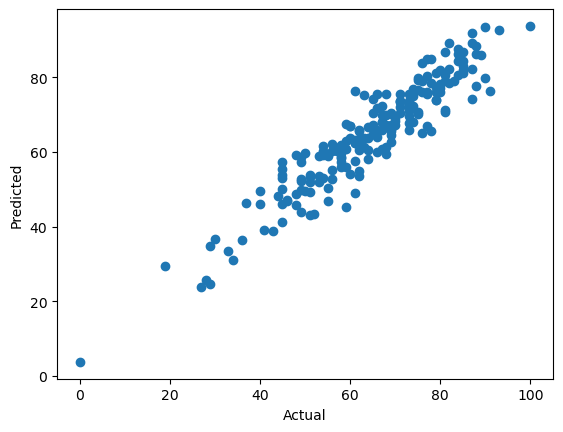

In [22]:
plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

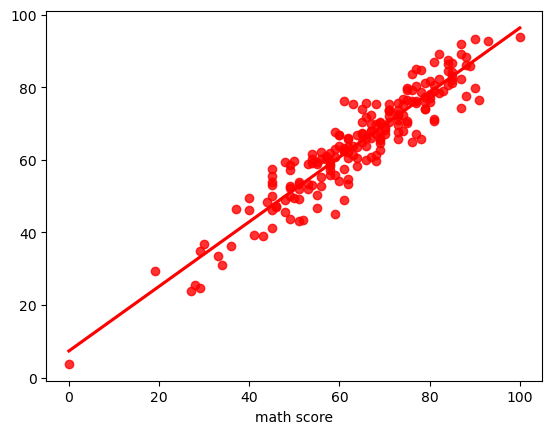

In [23]:
sns.regplot(x=y_test,y=y_pred,ci=None,color ='red');

### Difference between Actual and Predicted Values

In [24]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
